In [3]:
#import all the necessary libraries
import numpy as np
from scipy.optimize import curve_fit as cf
import matplotlib.pyplot as plt
plus_or_minus= '\u00B1'

#read the lab data for exercise 1
data = np.loadtxt("Electron Spin Data - Sheet1.csv",delimiter=',',comments="#",unpack=True, skiprows=1)
f = data[0]
uf_reading = data[1]
B = data[6]
uB = data[7]
pi = 3.14
e = 1.602*(10**-19)
m = 9.109*(10**-31)

#construct the model that relates stopping voltage to frequency of LED
def ESR(b, gamma, offset):
    v = (1/(2*pi))*gamma*b+offset
    return v

#curvefit time
popt_pre, pcov_pre = cf(ESR, B, f, absolute_sigma=True, sigma = uf_reading)
uf = np.sqrt((uf_reading**2)+((uB*popt_pre[0]/(2*pi))**2))

popt, pcov = cf(ESR, B, f, absolute_sigma=True, sigma = uf)
print(f"predicted gamma is {popt[0]:.5g}{plus_or_minus}{np.sqrt(pcov[0,0]):.1g}")
g = popt[0]*(10**6)*2*m/e
ug = np.sqrt(pcov[0,0])*(10**6)*2*m/e
print(f"predicted g factor is {g:.6g}{plus_or_minus}{ug:.1g}")

#Chi-square Calculation
def chi2(measured,predicted,error):
    return np.sum( (measured - predicted)**2 / error**2 )

def chi2reduced(y_measure, y_predict, errors, number_of_parameters):
    return chi2(y_measure, y_predict, errors)/(y_measure.size - number_of_parameters)

chi2Value = chi2(f, ESR(B, popt[0], popt[1]),uf)
RChi2Value = chi2reduced(f, ESR(B, popt[0], popt[1]),uf,3)
print(f"chi2 is {chi2Value:.5g}")
print(f"reduced chi2 is {RChi2Value:.5g}")

predicted gamma is 2.0635e+05±6e+04
predicted g factor is 2.34661±0.7
chi2 is 0.023028
reduced chi2 is 0.0017714


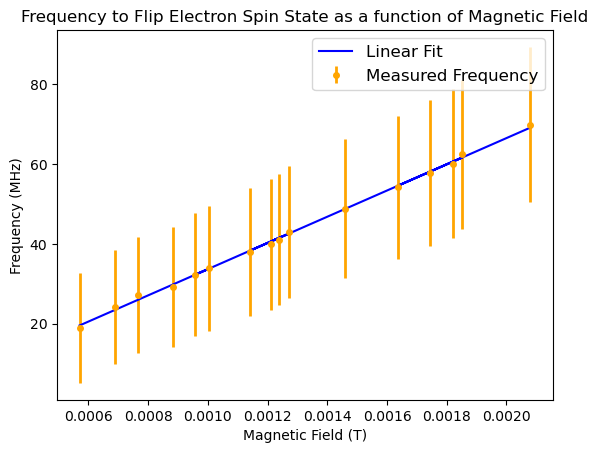

In [4]:
plt.figure()
plt.title("Frequency to Flip Electron Spin State as a function of Magnetic Field")
plt.xlabel("Magnetic Field (T)")
plt.ylabel("Frequency (MHz)")
plt.errorbar(B, f, yerr=uf,color='orange',marker='o',ls='',lw=2,ms=4, label ="Measured Frequency")
plt.plot(B, ESR(B, popt[0], popt[1]), "b-", label = "Linear Fit")
plt.legend(fontsize = 12)

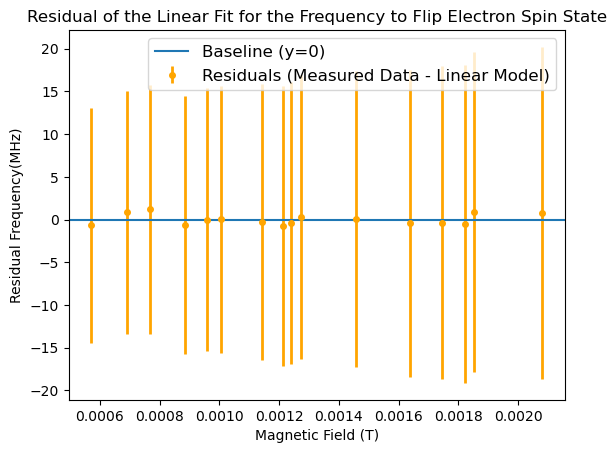

In [5]:
#PLOT the resisdual plot
plt.errorbar(B, f-ESR(B, popt[0], popt[1]), yerr=uf,color='orange',marker='o',ls='',lw=2,ms=4,label="Residuals (Measured Data - Linear Model)")
plt.axhline(y=0, label = "Baseline (y=0)")
plt.xlabel("Magnetic Field (T)")
plt.ylabel("Residual Frequency(MHz)")
plt.title("Residual of the Linear Fit for the Frequency to Flip Electron Spin State")
plt.legend(fontsize = 12)